In [1]:
import torch
import hydra
import numpy as np
import matplotlib.pyplot as plt
from omegaconf import DictConfig, OmegaConf
from solo.args.pretrain import parse_cfg
from solo.methods.ta import BYOLWithTA
from hydra import compose, initialize
from solo.losses.byol import byol_loss_func

from pytorch_lightning import seed_everything

from solo.methods import METHODS

from solo.data.pretrain_dataloader import (
    FullTransformPipeline,
    NCropAugmentation,
    build_transform_pipeline,
    prepare_dataloader,
    prepare_datasets,
)

import torch.nn.functional as F

/home/adondera/projects/manifold-ta/venv/lib/python3.9/site-packages/pl_bolts/models/self_supervised/amdim/amdim_module.py:35: UnderReviewWarning: The feature generate_power_seq is currently marked under review. The compatibility with other Lightning projects is not guaranteed and API may change at any time. The API and functionality may change without warning in future releases. More details: https://lightning-bolts.readthedocs.io/en/latest/stability.html
  "lr_options": generate_power_seq(LEARNING_RATE_CIFAR, 11),
/home/adondera/projects/manifold-ta/venv/lib/python3.9/site-packages/pl_bolts/models/self_supervised/amdim/amdim_module.py:93: UnderReviewWarning: The feature FeatureMapContrastiveTask is currently marked under review. The compatibility with other Lightning projects is not guaranteed and API may change at any time. The API and functionality may change without warning in future releases. More details: https://lightning-bolts.readthedocs.io/en/latest/stability.html
  contrast

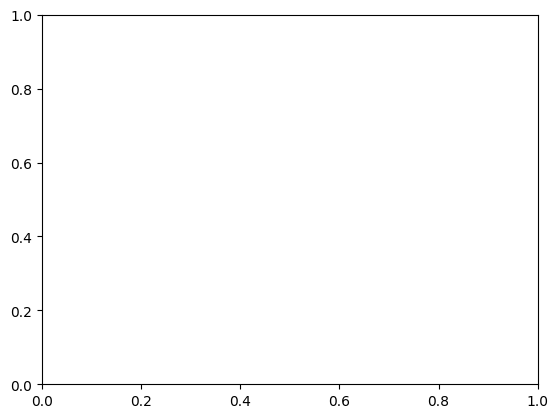

In [2]:
%matplotlib inline

fig, ax = plt.subplots()

In [29]:
with initialize(version_base=None, config_path="scripts/pretrain/cifar"):
    cfg = compose(config_name="byol-ta.yaml")

OmegaConf.set_struct(cfg, False)
cfg = parse_cfg(cfg)
seed_everything(cfg.seed)
model = METHODS[cfg.method](cfg)

# Load a pretrained model
path = "byol-ta/vu1q7sxr/byol-ta-cifar10-single-branch-bn-adamw-512batch-vu1q7sxr-ep=95.ckpt"
weights = torch.load(path)
model.load_state_dict(weights['state_dict'])
model.eval()

Global seed set to 5


RuntimeError: Error(s) in loading state_dict for BYOLWithTA:
	Missing key(s) in state_dict: "query_matrix.weight", "key_matrix.weight", "value_matrix.weight", "momentum_query_matrix.weight", "momentum_key_matrix.weight", "momentum_value_matrix.weight". 
	Unexpected key(s) in state_dict: "query_matrix.0.weight", "query_matrix.1.weight", "query_matrix.1.bias", "query_matrix.1.running_mean", "query_matrix.1.running_var", "query_matrix.1.num_batches_tracked", "key_matrix.0.weight", "key_matrix.1.weight", "key_matrix.1.bias", "key_matrix.1.running_mean", "key_matrix.1.running_var", "key_matrix.1.num_batches_tracked", "value_matrix.0.weight", "value_matrix.1.weight", "value_matrix.1.bias", "value_matrix.1.running_mean", "value_matrix.1.running_var", "value_matrix.1.num_batches_tracked", "momentum_query_matrix.0.weight", "momentum_query_matrix.1.weight", "momentum_query_matrix.1.bias", "momentum_query_matrix.1.running_mean", "momentum_query_matrix.1.running_var", "momentum_query_matrix.1.num_

In [5]:
pipelines = []
for aug_cfg in cfg.augmentations:
    pipelines.append(
        NCropAugmentation(
            build_transform_pipeline(cfg.data.dataset, aug_cfg), aug_cfg.num_crops
        )
    )
transform = FullTransformPipeline(pipelines)

if cfg.debug_augmentations:
    print("Transforms:")
    print(transform)

train_dataset = prepare_datasets(
    cfg.data.dataset,
    transform,
    train_data_path=cfg.data.train_path,
    data_format=cfg.data.format,
    no_labels=cfg.data.no_labels,
    data_fraction=cfg.data.fraction,
)
train_loader = prepare_dataloader(
    train_dataset, batch_size=cfg.optimizer.batch_size, num_workers=cfg.data.num_workers
)

Files already downloaded and verified


In [6]:
train_loader_iterator = iter(train_loader)

In [7]:
img_batch = next(train_loader_iterator)
with torch.no_grad():
    model_inputs = img_batch[1][0]
output = model(model_inputs)

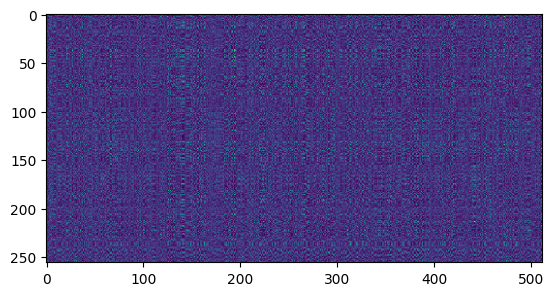

In [8]:
ax.imshow(output['feats'].detach().numpy())
fig

In [14]:
def attention_weights(model, batch):
    out = super(type(model), model).training_step(batch, 0)
    student_z = []
    neg_cos_sim = 0
    student_weights_list = []
    teacher_weights_list = []
    student_out = []
    for idx1 in range(model.num_large_crops):
            for idx2 in np.delete(range(model.num_crops), idx1):
                z = model.projector(out["feats"][idx1])
                student_z.append(z)
                with torch.no_grad():
                    momentum_z = model.momentum_projector(out["momentum_feats"][idx2])
                student_queries = model.query_matrix(z)
                student_keys = model.key_matrix(z)
                student_values = model.value_matrix(z)

                with torch.no_grad():
                    teacher_queries = model.momentum_query_matrix(momentum_z)
                    teacher_keys = model.momentum_key_matrix(momentum_z)
                    teacher_values = model.momentum_value_matrix(momentum_z)

                key_pool = (
                    torch.cat([student_keys, teacher_keys.detach()])
                    .transpose(0, 1)
                    .contiguous()
                )
                value_pool = torch.cat([student_values, teacher_values.detach()])

                d = student_queries.shape[-1]
#                 student_weights = torch.nn.functional.softmax(
#                     torch.mm(student_queries, key_pool) / np.sqrt(d),
#                     dim=-1,
#                 )
                student_weights = torch.nn.functional.softmax(
                    torch.mm(student_queries, student_keys.transpose(0,1)) / np.sqrt(d),
                    dim=-1,
                )

#                 student_y = torch.mm(student_weights, value_pool)
                student_y = torch.mm(student_weights, student_values)
                student_out.append(student_y)
                p = model.predictor(student_y)

                with torch.no_grad():
#                     teacher_weights = torch.nn.functional.softmax(
#                         torch.mm(teacher_queries, key_pool) / np.sqrt(d),
#                         dim=-1,
#                     )
                    
#                     teacher_y = torch.mm(teacher_weights, value_pool)
                    
                    teacher_weights = torch.nn.functional.softmax(
                        torch.mm(teacher_queries, teacher_keys.transpose(0,1)) / np.sqrt(d),
                        dim=-1,
                    )
                    
                    teacher_y = torch.mm(teacher_weights, teacher_values)
                teacher_weights_list.append(teacher_weights)
                neg_cos_sim += byol_loss_func(p, teacher_y)
                
                student_weights_list.append(student_weights)
                teacher_weights_list.append(teacher_weights)

#         with torch.no_grad():
#             z_std = (
#                 torch.nn.functional.normalize(torch.stack(student_z[: model.num_large_crops]), dim=-1)
#                 .std(dim=1)
#                 .mean()
#             )
#     print(z_std)
    return student_weights_list, teacher_weights_list, neg_cos_sim, student_z, student_out

In [15]:
with torch.no_grad():
    s_w, t_w, loss, proj_features, student_outs = attention_weights(model, img_batch)

In [22]:
s_w[0].argmax(dim=-1)

tensor([  0,   1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,  13,
         14,  15,  16,  17,  18,  19,  20,  21,  22,  23,  24,  25,  26,  27,
         28,  29,  30,  31,  32,  33,  34,  35,  36,  37,  38,  39,  40,  41,
         42,  43,  44, 112,  46,  47,  48,  49,  50,  51,  52,  53,  54,  15,
         56,  57,  58,  59,  60,  61,  62,  63,  64,  65,  66,  67,  68,  69,
         70,  71,  72,  73,  74,  75,  76,  77,  78,  79, 207,  81,  82,  83,
         84,  85,  86, 132,  88,  89,  90,  91,  92,  93,  94,  95,  96,  97,
         98,  99, 101, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111,
        112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125,
        126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139,
        140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153,
        154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167,
        168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 1

In [23]:
t_w[0].argmax(dim=-1)

tensor([  0,   1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,  13,
         14,  15,  16,  17,  18,  19,  20,  21,  22,  23,  24,  25,  26,  27,
         28,  29,  30,  31,  32,  33,  34,  35,  36,  37,  38,  39,  40,  41,
         42,  43,  44,  45,  46,  47,  48,  49,  50,  51,  52,  53,  54,  55,
         56,  57,  58,  59,  60,  61,  62,  63,  64,  65,  66,  67,  68,  69,
         70,  71,  72,  73,  74,  75,  76,  77,  78,  79,  80,  81,  82,  83,
         84,  85,  86,  87,  88, 241,  90,  91,  92,  93,  94,  95,  96,  97,
        150,  99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111,
        112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125,
        126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139,
        140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153,
        154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167,
        168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 1

In [28]:
F.normalize(torch.stack(student_outs), dim=-1).std(dim=1).mean()

tensor(0.0453)

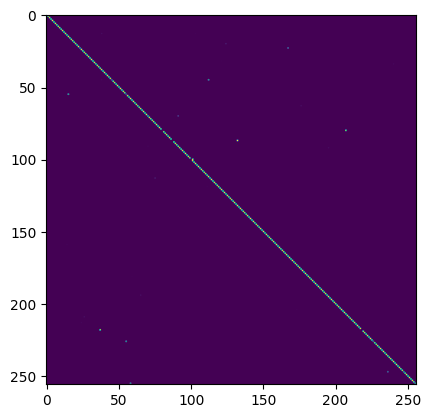

In [13]:
ax.imshow(s_w[0].detach().numpy())
fig

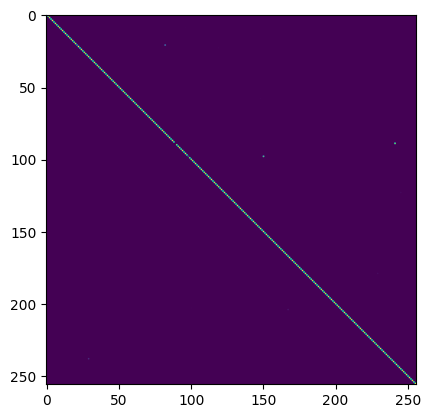

In [34]:
ax.imshow(t_w[0].detach().numpy())
fig

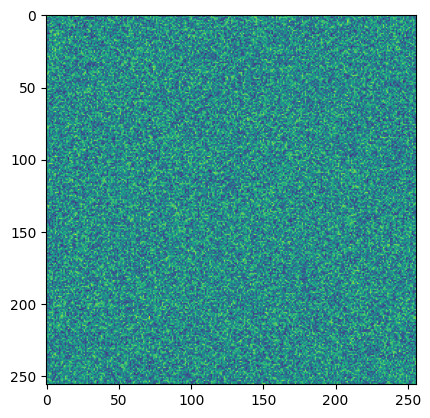

In [35]:
ax.imshow(model.query_matrix.weight.detach().numpy())
fig

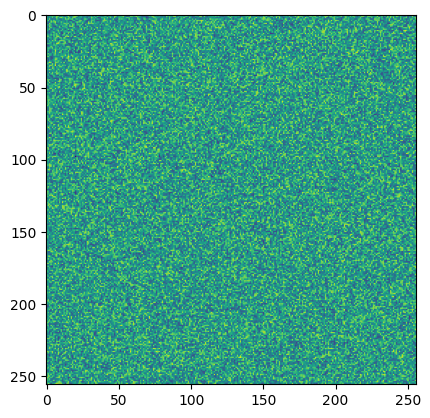

In [36]:
ax.imshow(model.key_matrix.weight.detach().numpy())
fig

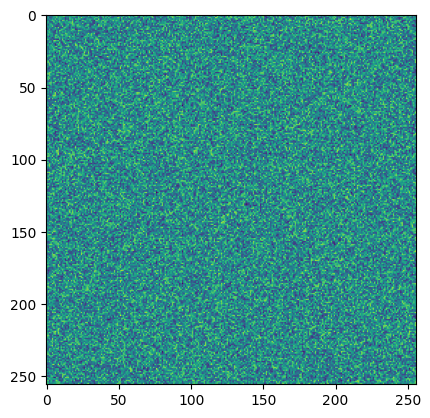

In [37]:
ax.imshow(model.value_matrix.weight.detach().numpy())
fig

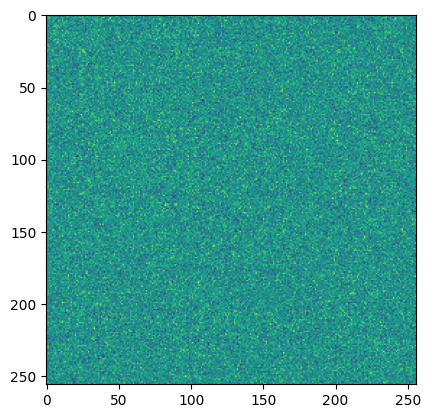

In [38]:
ax.imshow(torch.mm(model.query_matrix.weight.data, model.key_matrix.weight.data.transpose(0,1)))
fig

In [46]:
student_queries = model.query_matrix(proj_features[0])
student_keys = model.key_matrix(proj_features[0])
student_values = model.value_matrix(proj_features[0])

teacher_queries = model.momentum_query_matrix(proj_features[1])
teacher_keys = model.momentum_key_matrix(proj_features[1])
teacher_values = model.momentum_value_matrix(proj_features[1])

d = student_queries.shape[-1]

# ax.imshow((torch.mm(student_queries, student_keys.transpose(0,1)) / np.sqrt(d)).detach().numpy())
# fig
# print((torch.mm(student_queries, student_keys.transpose(0,1)) / 16)[0, 245])
# print((torch.mm(student_queries, student_keys.transpose(0,1)) / 16)[0, 17])
# print(F.softmax(torch.mm(student_queries, student_keys.transpose(0,1)) / np.sqrt(d), dim=-1)[0, 245])
# print(F.softmax(torch.mm(student_queries, student_keys.transpose(0,1)) / np.sqrt(d), dim=-1)[0, 17])
torch.topk(torch.mm(student_queries, student_keys.transpose(0,1)) / 16, 2, dim=-1)
torch.topk(F.softmax(torch.mm(student_queries, student_keys.transpose(0,1)) / np.sqrt(d), dim=-1), 2, dim=-1)
# ax.imshow(F.softmax(torch.mm(student_queries, student_keys.transpose(0,1)) / np.sqrt(d), dim=-1).detach().numpy())
# fig
# torch.argmax(torch.mm(student_queries, student_keys.transpose(0,1)), dim=-1)

torch.return_types.topk(
values=tensor([[9.8964e-01, 1.0358e-02],
        [1.0000e+00, 3.3112e-18],
        [1.0000e+00, 4.5092e-16],
        [1.0000e+00, 1.4546e-17],
        [9.9999e-01, 1.1209e-05],
        [1.0000e+00, 5.3772e-17],
        [1.0000e+00, 6.2140e-11],
        [1.0000e+00, 5.4344e-11],
        [1.0000e+00, 1.1282e-09],
        [1.0000e+00, 1.2600e-12],
        [9.9968e-01, 3.0979e-04],
        [1.0000e+00, 4.2331e-10],
        [9.9931e-01, 6.9015e-04],
        [9.5564e-01, 3.5491e-02],
        [1.0000e+00, 8.4732e-09],
        [1.0000e+00, 1.4735e-25],
        [1.0000e+00, 6.9552e-07],
        [1.0000e+00, 6.7877e-08],
        [1.0000e+00, 6.0601e-14],
        [1.0000e+00, 7.7706e-17],
        [9.2340e-01, 7.6597e-02],
        [1.0000e+00, 1.2801e-13],
        [1.0000e+00, 7.5207e-19],
        [6.3495e-01, 3.6505e-01],
        [1.0000e+00, 1.2646e-06],
        [1.0000e+00, 5.0638e-14],
        [1.0000e+00, 8.0441e-13],
        [1.0000e+00, 3.7111e-28],
        [1.0000e